In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import log_loss
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Poisson as psn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.api import Holt
from statsmodels.tsa.api import ExponentialSmoothing

In [2]:
df = pd.read_csv('../Datasets/flights_sample_3m.csv')


In [3]:
df_col= df.columns
for i in df_col:
    df[i.lower()] = df[i]
    df = df.drop(i,axis=1)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   fl_date                  str    
 1   airline                  str    
 2   airline_dot              str    
 3   airline_code             str    
 4   dot_code                 int64  
 5   fl_number                int64  
 6   origin                   str    
 7   origin_city              str    
 8   dest                     str    
 9   dest_city                str    
 10  crs_dep_time             int64  
 11  dep_time                 float64
 12  dep_delay                float64
 13  taxi_out                 float64
 14  wheels_off               float64
 15  wheels_on                float64
 16  taxi_in                  float64
 17  crs_arr_time             int64  
 18  arr_time                 float64
 19  arr_delay                float64
 20  cancelled                float64
 21  cancellation_code  

In [5]:
df.describe()

,dot_code,fl_number,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,diverted,crs_elapsed_time,elapsed_time,air_time,distance,delay_due_carrier,delay_due_weather,delay_due_nas,delay_due_security,delay_due_late_aircraft
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,2.920058e+06,2.913802e+06,3.000000e+06,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,1.466511e+03,4.260858e+00,2.638000e-02,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,5.318383e+02,5.117482e+01,1.602626e-01,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,1.053000e+03,-1.600000e+01,0.000000e+00,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,1.505000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,1.913000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,2.400000e+03,2.934000e+03,1.000000e+00,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [6]:
# Shape of data
row, col = df.shape
print(f'Dataset shape: {row} rows and {col} columns.')

Dataset shape: 3000000 rows and 32 columns.


### Handle Missing Value

In [7]:
# Finding the missing values in columns
missing = df.isnull().mean()
miss_col = missing[missing>0].sort_values(ascending=False)

for key,value in miss_col.items():
    print(f'{key} : {value:.2f}')

cancellation_code : 0.97
delay_due_weather : 0.82
delay_due_nas : 0.82
delay_due_security : 0.82
delay_due_late_aircraft : 0.82
delay_due_carrier : 0.82
air_time : 0.03
elapsed_time : 0.03
arr_delay : 0.03
taxi_in : 0.03
wheels_on : 0.03
arr_time : 0.03
taxi_out : 0.03
wheels_off : 0.03
dep_delay : 0.03
dep_time : 0.03
crs_elapsed_time : 0.00


In [8]:
# Cancellation code filled with 'None' values
df['cancellation_code'] = df['cancellation_code'].fillna('None')

In [9]:
# Cancelled flights do not have an arr_delay value
non_cancelled_missing = df[(df['cancelled'] == 0) & (df['arr_delay'].isnull())].shape[0]
df = df[(df['cancelled'] == 1) | (df['arr_delay'].notnull())]
df = df.reset_index(drop=True)
df['arr_delay'] = df['arr_delay'].fillna(0)
print(f"Removed {non_cancelled_missing} non-cancelled rows with missing arr_delay.")
print(f"Cancelled flights are preserved.")
print(f"Dataset now has {len(df)} rows (including {df['cancelled'].sum()} cancelled flights).")

Removed 7058 non-cancelled rows with missing arr_delay.
Cancelled flights are preserved.
Dataset now has 2992942 rows (including 79140.0 cancelled flights).


In [10]:
# Fill delay breakdown categories with 0.0 minutes
delay_due_cols = [
    'delay_due_carrier','delay_due_weather',
    'delay_due_nas','delay_due_security',
    'delay_due_late_aircraft'
]
df[delay_due_cols] = df[delay_due_cols].fillna(0.0)

In [11]:
# Cancellation break-down
cancel_map = {
    'A' : 'Security',
    'B' : 'Weather',
    'C' : 'NAS',
    'D' : 'Lack_Passengers'
}

df['cancellation_code'] = df['cancellation_code'].replace(cancel_map).fillna('Not Cancelled')

In [12]:
# These are all missing because cancelled flights never took off.
print("Remaining Null Values:")
print(df.isnull().sum())

Remaining Null Values:
fl_date                        0
airline                        0
airline_dot                    0
airline_code                   0
dot_code                       0
fl_number                      0
origin                         0
origin_city                    0
dest                           0
dest_city                      0
crs_dep_time                   0
dep_time                   77615
dep_delay                  77644
taxi_out                   78806
wheels_off                 78806
wheels_on                  79140
taxi_in                    79140
crs_arr_time                   0
arr_time                   79140
arr_delay                      0
cancelled                      0
cancellation_code              0
diverted                       0
crs_elapsed_time              14
elapsed_time               79140
air_time                   79140
distance                       0
delay_due_carrier              0
delay_due_weather              0
delay_due_nas       

#### Mean flight delayed

In [13]:
# Flights which are delayed by 20 min
delay_flight = df[df['arr_delay'] > 20]

# DELAY_DUE_CARRIER, DELAY_DUE_WEATHER, DELAY_DUE_NAS, DELAY_DUE_SECURITY, DELAY_DUE_LATE_AIRCRAFT
delay_cause = ['delay_due_carrier','delay_due_weather',
    'delay_due_nas','delay_due_security',
    'delay_due_late_aircraft']
causes_mean = delay_flight[delay_cause].mean().sort_values(ascending=False)
total_causes_mean = delay_flight[delay_cause].sum(axis=1).mean()
print('How much percent is captured by each causes to delay any flights.')
for key, value in causes_mean.items():
    percent = (value / total_causes_mean) * 100
    print(f'{key.replace("_", " ").title():<25} : {value:.2f} mins ({percent:.2f}%)')


How much percent is captured by each causes to delay any flights.
Delay Due Late Aircraft   : 30.16 mins (38.40%)
Delay Due Carrier         : 28.86 mins (36.75%)
Delay Due Nas             : 14.57 mins (18.55%)
Delay Due Weather         : 4.79 mins (6.09%)
Delay Due Security        : 0.16 mins (0.21%)


#### Flight Summary

In [14]:
# Convert the 'date' column to datetime format
df['fl_date'] = pd.to_datetime(df['fl_date'])

# Extract year, month, and day into separate columns
df['year'] = df['fl_date'].dt.year
df['month'] = df['fl_date'].dt.month
df['day'] = df['fl_date'].dt.day
df['days_of_month'] = df['fl_date'].dt.days_in_month
df['day_of_week'] = df['fl_date'].dt.dayofweek
df['day_name'] = df['fl_date'].dt.strftime("%a")
df['month_name'] = df['fl_date'].dt.strftime("%b")

In [15]:
# 1. Calculate cancellation rates on the full dataset
cancellation_rates = df.groupby('airline_code')['cancelled'].mean() * 100
# 2. Filter the dataset for delay analysis
df_filtered = df[(df['cancelled'] == 0) & (df['diverted'] == 0)]
# 3. Aggregate delay statistics
summary = df_filtered.groupby('airline_code').agg(
    flight_count=('year', 'count'),
    mean_arr_delay=('arr_delay', 'mean')
)
# 4. Map the pre-calculated cancellation rates back to the summary
summary['cancellation_rate'] = summary.index.map(cancellation_rates)
summary

,flight_count,mean_arr_delay,cancellation_rate
airline_code,,,
9E,109848,-1.258539,2.132891
AA,371218,6.661229,2.854302
AS,98294,1.097900,1.929601
B6,109447,12.276125,2.701670
DL,388475,1.085079,1.516515
EV,17951,10.031976,5.585652
F9,62711,11.100429,2.587881
G4,50179,13.284601,4.533694
HA,31698,3.894757,1.209250


## Feature Engineering

In [16]:
# 'crs_dep_time' stores time as a 4-digit number, e.g. 1430 means 2:30 PM
df['dep_hour'] = df['crs_dep_time'] // 100
df['arr_hour'] = df['crs_arr_time'] // 100

In [17]:
# Morning peak: 7am, 8am, 9am  |  Evening peak: 5pm, 6pm, 7pm
peak_hours = [7, 8, 9, 17, 18, 19]
df['is_peak_hour'] = df['dep_hour'].isin(peak_hours).astype(int)

In [18]:
# Early morning flights usually have less delay because the aircraft is fresh
df['is_early_dep'] = (df['dep_hour'] < 7).astype(int)

In [19]:
# --- Is it a red-eye flight (departure after 10pm or before 5am)? ---
df['is_red_eye'] = ((df['dep_hour'] >= 22) | (df['dep_hour'] <= 4)).astype(int)

In [20]:
# In the dataset: day_of_week 1=Monday, ..., 6=Saturday, 7=Sunday
df['is_weekend'] = df['day_of_week'].isin([6, 7]).astype(int)

In [21]:
# Summer months have the most flight delays due to thunderstorms
df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)

In [22]:
# Winter months have the most cancellations due to snow and ice
df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)

In [23]:
# quarter 1 = Jan-Mar, 2 = Apr-Jun, 3 = Jul-Sep, 4 = Oct-Dec
df['quarter'] = pd.to_datetime(df['fl_date']).dt.quarter

In [24]:
# Certain routes are known to be more delay-prone than others
df['route'] = df['origin'] + '_' + df['dest']

In [25]:
# --- Is it a long flight (more than 1500 miles)? ---
df['is_long_flight'] = (df['distance'] > 1500).astype(int)

In [26]:
# --- Is it a short flight (less than 500 miles)? ---
df['is_short_flight'] = (df['distance'] < 500).astype(int)

In [27]:
# Average airplane speed is about 450 mph = 7.5 miles per minute
df['block_buffer'] = (df['crs_elapsed_time'] - (df['distance'] / 7.5)).round(2)

In [28]:
print(f"  Peak hour departures  : {df['is_peak_hour'].mean()*100:.1f}%")
print(f"  Early morning dep     : {df['is_early_dep'].mean()*100:.1f}%")
print(f"  Red-eye flights       : {df['is_red_eye'].mean()*100:.1f}%")
print(f"  Weekend flights       : {df['is_weekend'].mean()*100:.1f}%")
print(f"  Summer flights        : {df['is_summer'].mean()*100:.1f}%")
print(f"  Winter season flights : {df['is_winter'].mean()*100:.1f}%")
print(f"  Long flights >1500mi  : {df['is_long_flight'].mean()*100:.1f}%")
print(f"  Short flights <500mi  : {df['is_short_flight'].mean()*100:.1f}%")
print(f"  Unique routes         : {df['route'].nunique():,}")
print(f"  Avg schedule buffer   : {df['block_buffer'].mean():.1f} mins")

  Peak hour departures  : 37.2%
  Early morning dep     : 9.5%
  Red-eye flights       : 3.4%
  Weekend flights       : 14.6%
  Summer flights        : 27.8%
  Winter season flights : 24.4%
  Long flights >1500mi  : 12.0%
  Short flights <500mi  : 36.2%
  Unique routes         : 7,779
  Avg schedule buffer   : 34.4 mins


### Descriptive Statistics


In [29]:
# primary theme 
sns.set_theme(style='whitegrid')

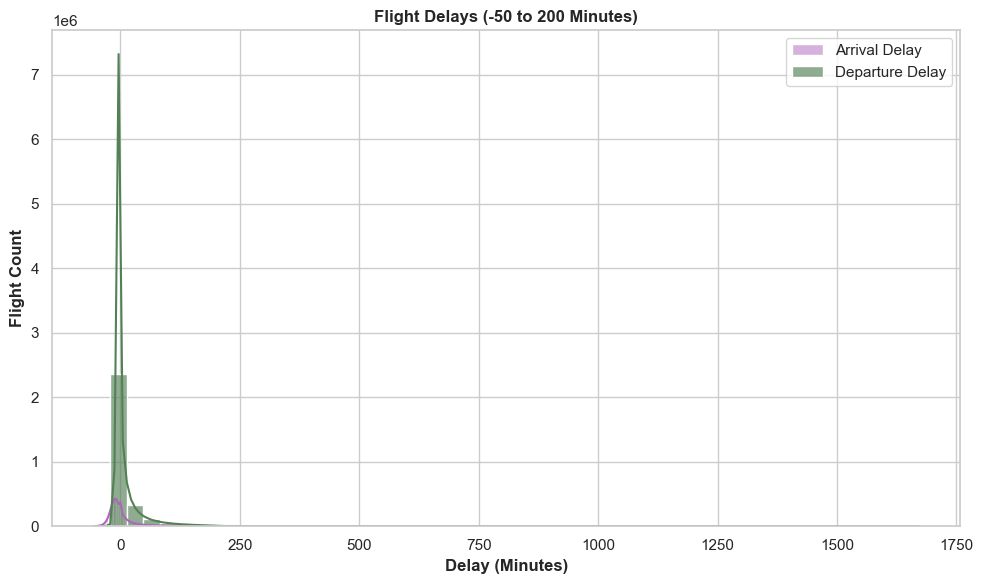

In [30]:
# Plot 1: Distribution of arrival and departure delays
data = df[(df['arr_delay'] >= -50) & (df['arr_delay'] < 200)]
plt.figure(figsize=(10,6))
sns.histplot(data=data,x='arr_delay',bins=50,color='#B065BD',label='Arrival Delay',kde=True)
sns.histplot(data=data,x='dep_delay',bins=50,color='#538055',alpha=0.65,label='Departure Delay',kde=True)
plt.title("Flight Delays (-50 to 200 Minutes)",loc='center',fontweight='bold')
plt.xlabel('Delay (Minutes)',fontweight='bold')
plt.ylabel('Flight Count',fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

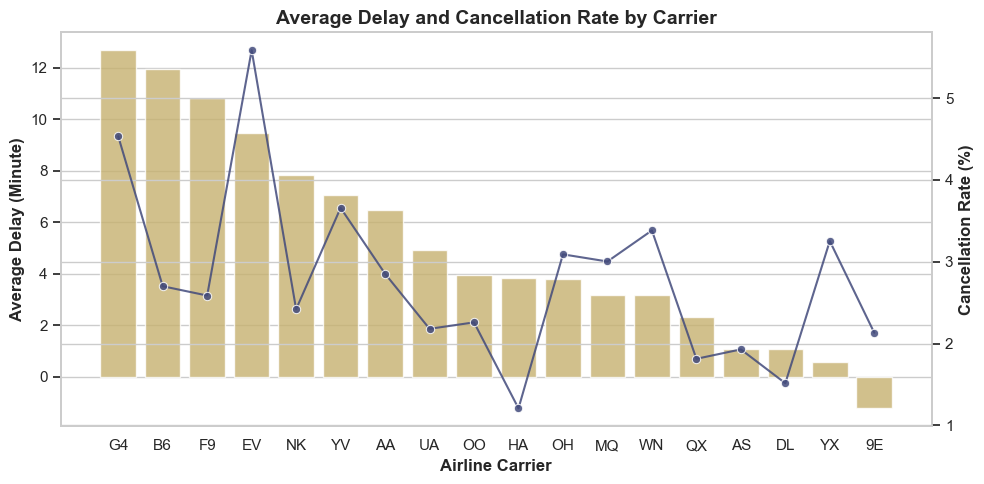

In [31]:
# Plot 2: Average delay and cancellation rate by airline

carrier = df.groupby('airline_code').agg(
    mean_arrival_delay=('arr_delay','mean'),
    cancellation_rate=('cancelled', lambda x: x.mean() * 100)
).sort_values(by="mean_arrival_delay",ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart (left y-axis)
sns.barplot(data=carrier, x=carrier.index, y='mean_arrival_delay', color='#D4B860', alpha=0.8)
ax1.set_xlabel('Airline Carrier', fontweight='bold')
ax1.set_ylabel('Average Delay (Minute)', fontweight='bold')

# Line chart (right y-axis)
ax2 = ax1.twinx()
sns.lineplot(data=carrier, x=carrier.index, y='cancellation_rate',ax=ax2, color='#424A7B', marker='o',alpha=0.85)
ax2.set_ylabel('Cancellation Rate (%)', fontweight='bold')

plt.title('Average Delay and Cancellation Rate by Carrier',fontweight='bold',fontsize=14)
plt.tight_layout()
plt.show()

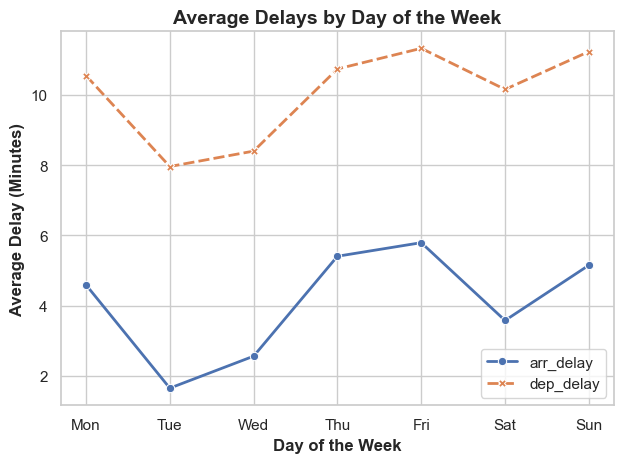

In [32]:
# Plot 3: Average delay by day of week
days = df.groupby('day_name').agg(
        arr_delay=('arr_delay', 'mean'),
        dep_delay=('dep_delay', 'mean')
    ).reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    
sns.lineplot(data=days, markers=True, linewidth=2)
plt.title('Average Delays by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontweight='bold')
plt.ylabel('Average Delay (Minutes)', fontweight='bold')
plt.tight_layout()
plt.show()

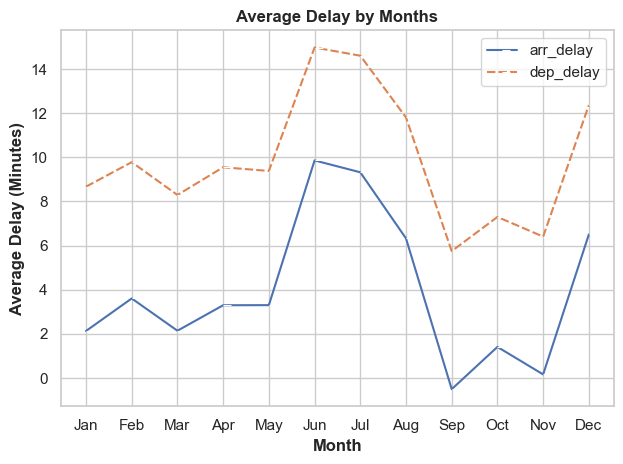

In [33]:
# Plot 4: Average delay by month (seasonal pattern)
months = df.groupby('month_name').agg(
    arr_delay=('arr_delay','mean'),
    dep_delay=('dep_delay','mean')
).reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

sns.lineplot(data=months,marker=True)
plt.title('Average Delay by Months',fontweight='bold')
plt.xlabel('Month',fontweight='bold')
plt.ylabel('Average Delay (Minutes)',fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

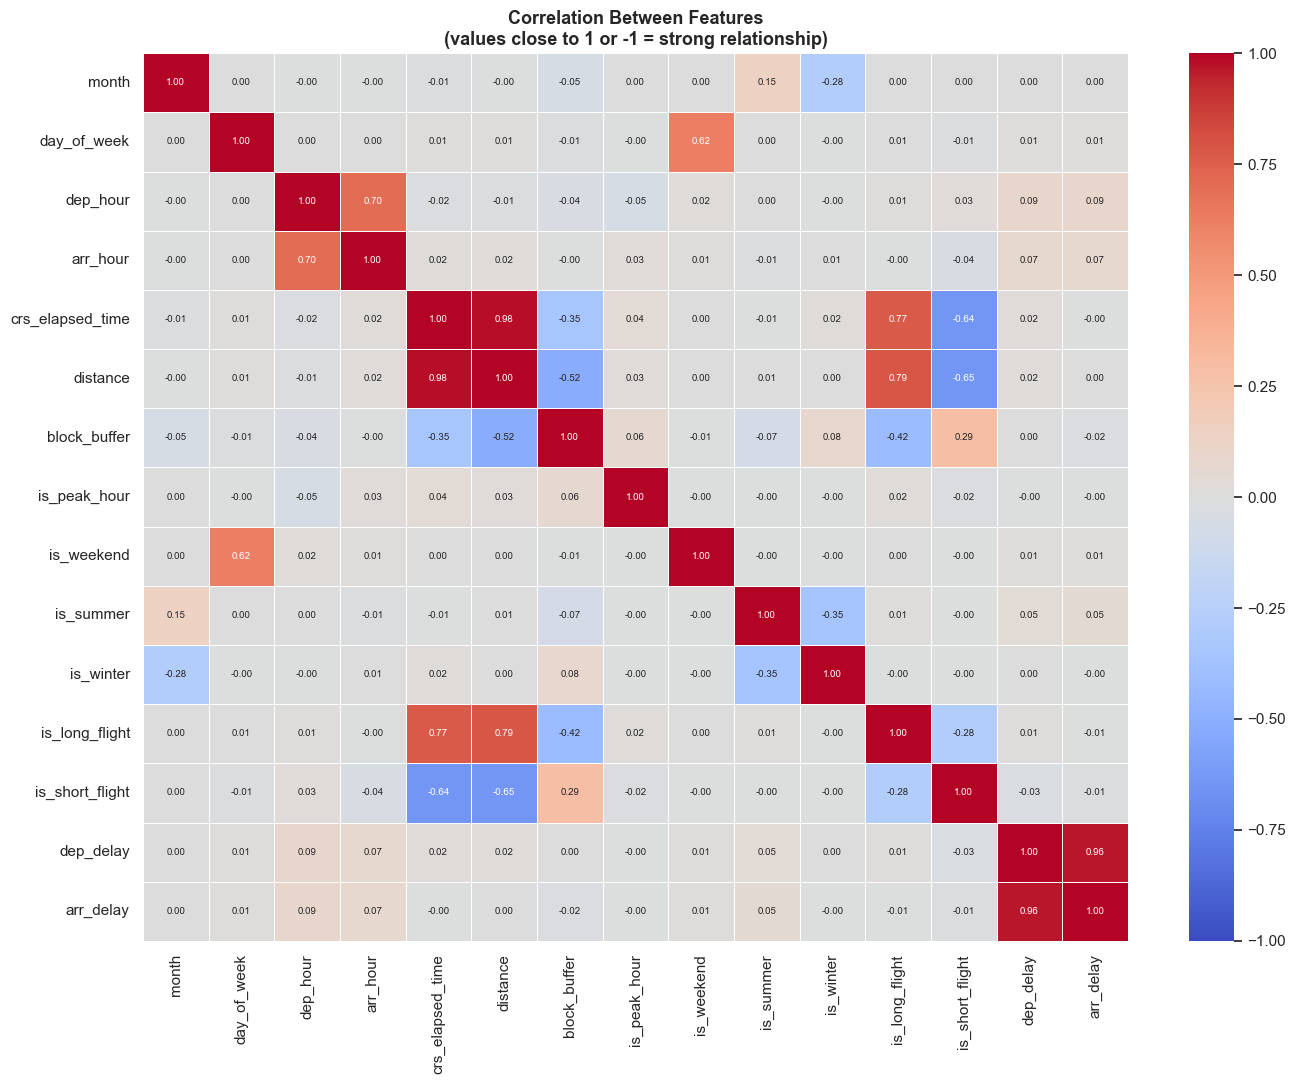

In [34]:
# Plot 5: Correlation heatmap
plt.figure(figsize=(12, 10))
heatmap_cols = [
        'month', 'day_of_month', 'day_of_week',
        'dep_hour', 'arr_hour',
        'crs_elapsed_time', 'distance', 'block_buffer',
        'is_peak_hour', 'is_weekend', 'is_summer', 'is_winter',
        'is_long_flight', 'is_short_flight',
        'dep_delay', 'arr_delay'
    ]

heatmap_cols = [c for c in heatmap_cols if c in df.columns]
corr = df[heatmap_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.4, vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Correlation Between Features\n(values close to 1 or -1 = strong relationship)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

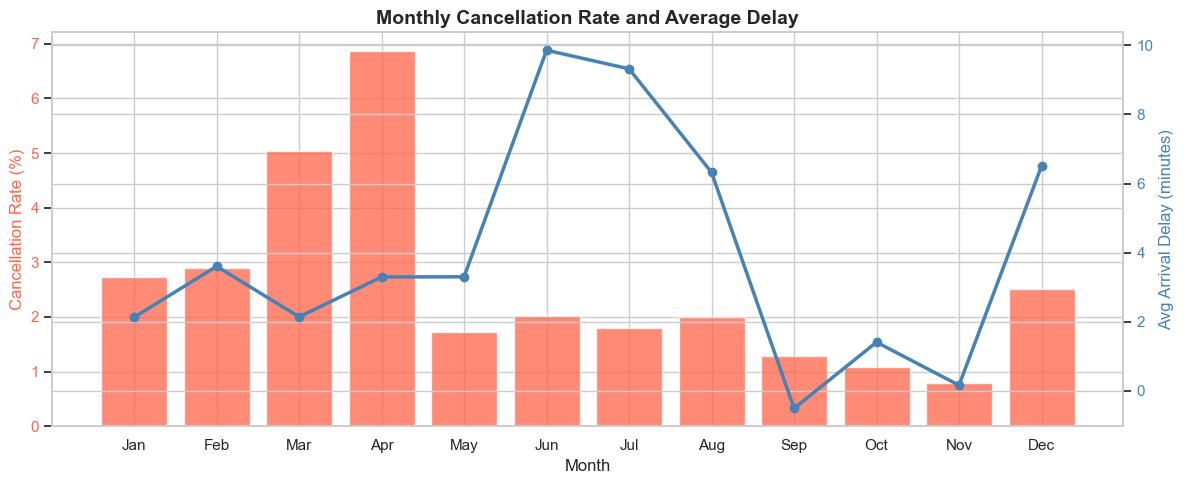

In [40]:
# Plot 7: Monthly cancellation rate vs average delay
month_wise = {
    1:'Jan', 2:'Feb',3:'Mar',4:'Apr',5:'May', 6:'Jun', 
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
monthly = df.groupby('month').agg(
    cancel_rate=('cancelled', lambda x: x.mean() * 100),
    avg_arr_delay=('arr_delay', 'mean')
).reset_index()
monthly['month_name'] = monthly['month'].map(month_wise)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly['month_name'], monthly['cancel_rate'],
            color='tomato', alpha=0.75, label='Cancellation Rate (%)')
ax1.set_ylabel('Cancellation Rate (%)', color='tomato', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tomato')
ax2 = ax1.twinx()
ax2.plot(monthly['month_name'], monthly['avg_arr_delay'],
        color='steelblue', marker='o', linewidth=2.5,
        label='Avg Arrival Delay')
ax2.set_ylabel('Avg Arrival Delay (minutes)', color='steelblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel('Month', fontsize=12)
plt.title('Monthly Cancellation Rate and Average Delay',
        fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

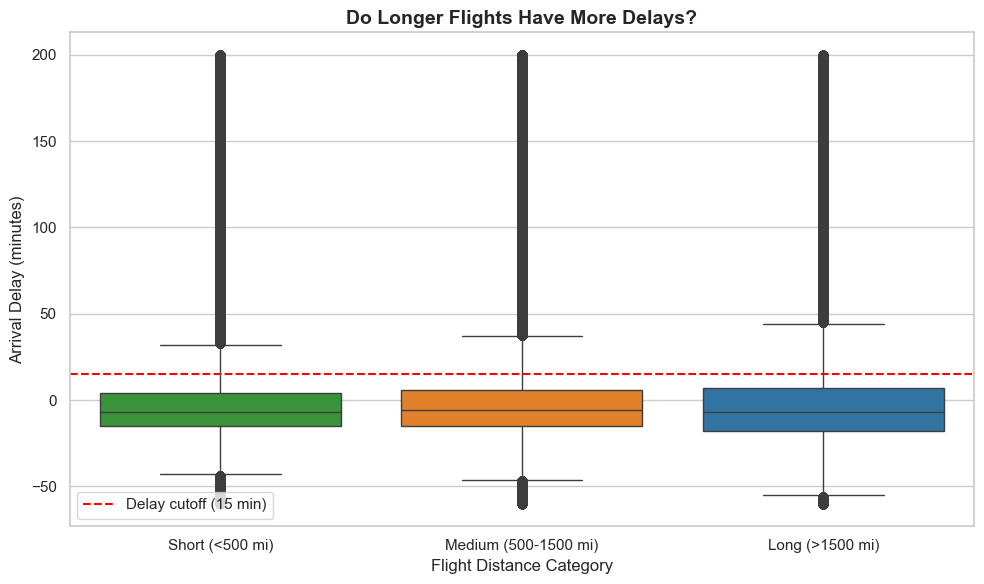

In [41]:
# Plot 8: Short vs Medium vs Long flight delay comparison
df['flight_type'] = 'Medium (500-1500 mi)'
df.loc[df['is_long_flight'] == 1, 'flight_type'] = 'Long (>1500 mi)'
df.loc[df['is_short_flight'] == 1, 'flight_type'] = 'Short (<500 mi)'

box_df = df[(df['arr_delay'] >= -60) & (df['arr_delay'] <= 200)].copy()
plt.figure(figsize=(10, 6))
order = ['Short (<500 mi)', 'Medium (500-1500 mi)', 'Long (>1500 mi)']
palette = {'Short (<500 mi)': '#2ca02c', 'Medium (500-1500 mi)': '#ff7f0e', 'Long (>1500 mi)': '#1f77b4'}
sns.boxplot(data=box_df, x='flight_type', y='arr_delay',
                hue='flight_type', order=order, palette=palette, legend=False)
plt.axhline(y=15, color='red', linestyle='--', label='Delay cutoff (15 min)')
plt.title('Do Longer Flights Have More Delays?',
              fontsize=14, fontweight='bold')
plt.xlabel('Flight Distance Category', fontsize=12)
plt.ylabel('Arrival Delay (minutes)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

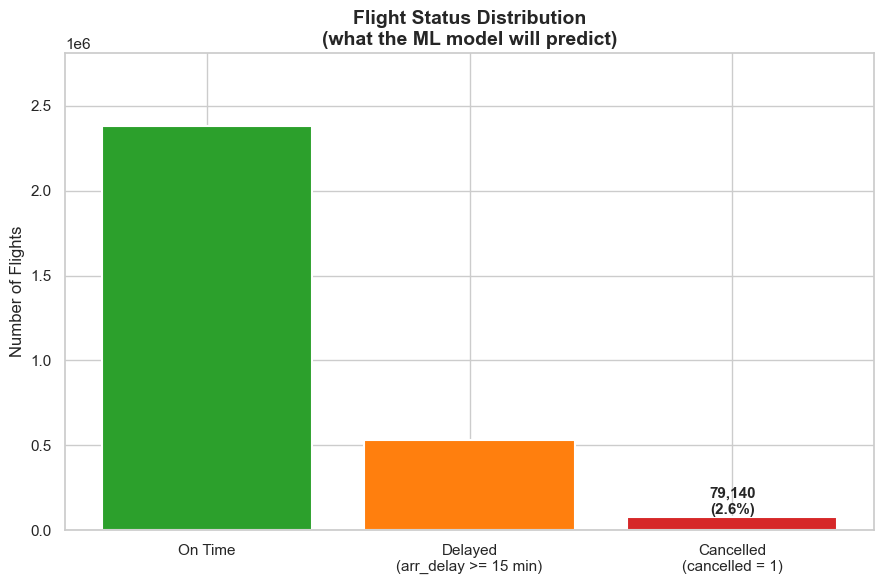

In [42]:
# Plot 10: 3-class target distribution (what we want to predict)
on_time_count   = ((df['cancelled'] == 0) & (df['arr_delay'] < 15)).sum()
delayed_count   = ((df['cancelled'] == 0) & (df['arr_delay'] >= 15)).sum()
cancelled_count = (df['cancelled'] == 1).sum()
total           = len(df)

labels = ['On Time', 'Delayed\n(arr_delay >= 15 min)', 'Cancelled\n(cancelled = 1)']
counts = [on_time_count, delayed_count, cancelled_count]
colors = ['#2ca02c', '#ff7f0e', '#d62728']

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    pct = count / total * 100
plt.text(bar.get_x() + bar.get_width() / 2,
         bar.get_height() + 200,
         f'{count:,}\n({pct:.1f}%)',
         ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Flight Status Distribution\n(what the ML model will predict)',
              fontsize=14, fontweight='bold')
plt.ylabel('Number of Flights', fontsize=12)
plt.ylim(0, max(counts) * 1.18)
plt.tight_layout()
plt.show()